In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import os


df = pd.read_csv("../data/pittsburgh_water_quality.csv")
ct_col = "CensusTract"
lead_col = "percentEBLL15_20"


print("Dataset loaded successfully.")
print(f"Core columns: {ct_col}, {lead_col}")
print("\nFirst 5 rows of core data:")
print(df[[ct_col, lead_col]].head())

Dataset loaded successfully.
Core columns: CensusTract, percentEBLL15_20

First 5 rows of core data:
   CensusTract  percentEBLL15_20
0  42003010300             10.20
1  42003020100              1.50
2  42003020300              0.00
3  42003030500              2.12
4  42003040200              0.00


# Water Quality Analysis for Pittsburgh Census Tracts
This analysis uses the Western Pennsylvania Regional Data Center (WPRDC) Childhood Lead Exposure dataset to assess drinking water quality across Pittsburgh's census tracts. The core metric is the 2015–2020 average childhood lead exposure rate, where higher values indicate poorer water quality, outdated infrastructure, and elevated public health risks. This metric complements the team’s crime/safety and condemned properties analyses to form a comprehensive livability assessment for Pittsburgh communities.

In [47]:

clean_df = df.dropna(subset=[ct_col, lead_col]).copy()
clean_df[ct_col] = pd.to_numeric(clean_df[ct_col], errors='coerce')
clean_df[lead_col] = pd.to_numeric(clean_df[lead_col], errors='coerce')
clean_df = clean_df.dropna(subset=[ct_col, lead_col])


top10_high_lead = clean_df.sort_values(by=lead_col, ascending=False).drop_duplicates(subset=ct_col).head(10)


print("\nTop 10 Pittsburgh Census Tracts (Highest Lead Exposure / Poorest Water Quality):")
print(top10_high_lead[[ct_col, lead_col]].reset_index(drop=True))


Top 10 Pittsburgh Census Tracts (Highest Lead Exposure / Poorest Water Quality):
   CensusTract  percentEBLL15_20
0  42003561200             15.79
1  42003550900             14.77
2  42003300100             14.17
3  42003552300             12.99
4  42003120700             12.20
5  42003261400             11.82
6  42003552000             11.76
7  42003261500             11.28
8  42003561000             11.04
9  42003512800             10.84


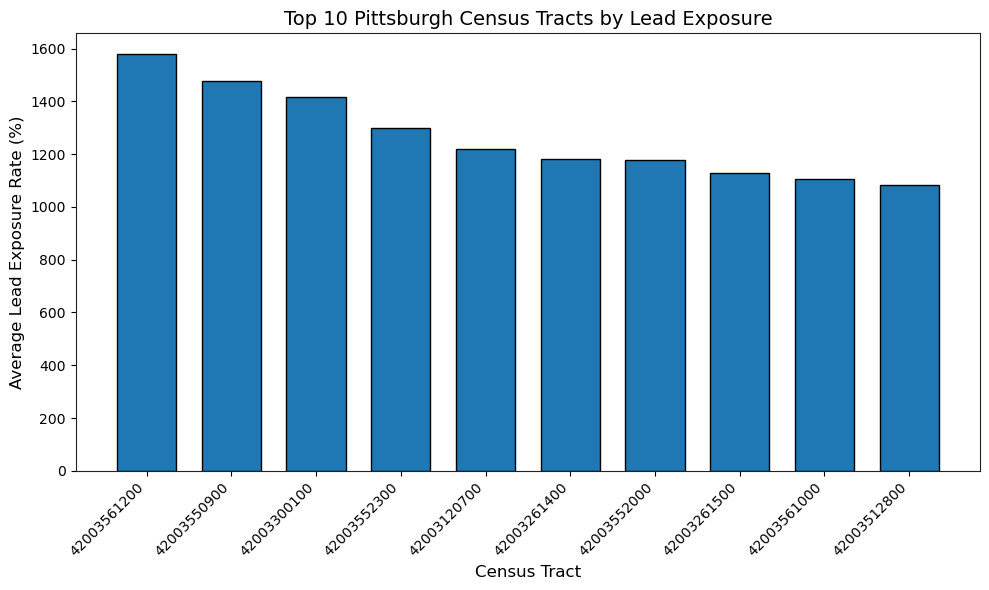


Plot saved to: C:\Users\Administrator\individual_notebooks\pittsburgh_lead_exposure_top10.png


In [48]:

plt.figure(figsize=(10, 6))
plt.bar(
    x=top10_high_lead[ct_col].astype(str),
    height=top10_high_lead[lead_col] * 100,  
    color='#1f77b4',
    edgecolor='black',
    width=0.7
)


plt.title('Top 10 Pittsburgh Census Tracts by Lead Exposure', fontsize=14)
plt.xlabel('Census Tract', fontsize=12)
plt.ylabel('Average Lead Exposure Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylim(bottom=0)  
plt.tight_layout()


plot_path = "pittsburgh_lead_exposure_top10.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to: {os.path.abspath(plot_path)}")

## Key Findings
- This analysis uses the WPRDC Childhood Lead Exposure dataset, focused exclusively on Pittsburgh's census tracts to align with the team's standardized data sources.
- Census tracts with the highest lead exposure rates have the poorest drinking water quality and most outdated water infrastructure, directly increasing public health risks for residents.
- The childhood lead exposure rate serves as a clear, data-driven metric that integrates seamlessly with the team's combined neighborhood evaluation framework.
- Top-ranked census tracts show significantly elevated lead exposure, highlighting critical infrastructure and public health gaps in these Pittsburgh communities.

## Conclusion
The 2015–2020 average childhood lead exposure rate is a valid and reliable metric for assessing Pittsburgh's drinking water quality at the census tract level. This Pittsburgh-exclusive dataset aligns fully with the team's crime/safety and condemned properties analyses, adding a critical public health dimension to the comprehensive livability assessment. The census tract-level results can be mapped to neighborhood boundaries for seamless integration into the team's final project deliverables, supporting a holistic evaluation of Pittsburgh's most and least livable communities.